#run_rl_experiments.py

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.2 MB/s eta 0:00:00


In [ ]:
# Эксперименты с RL-агентами на реальных матрицах ATSP.
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import json
import osmnx as ox

from preprocess import load_preprocessed_matrices, load_warehouse_info
from rl_environment import ATSPEnvironment
from rl_agents import (
    PolicyGradientAgent, A2CAgent, PPOAgent, DQNAgent, DoubleDQNAgent, SACAgent,
    EnhancedPolicyGradientAgent, EnhancedA2CAgent, EnhancedPPOAgent,
    ImprovedDQNAgent, ImprovedDoubleDQNAgent, EnhancedSACAgent
)
from classical import greedy_tsp, tsp_2opt, tabu_search_tsp
from utils import (
    calculate_route_distance, zip_folder, unzip_all,
    validate_route_on_graph, plot_route_on_map,
    load_rl_metrics
)

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {DEVICE}")

OUTPUT_DIR = "rl_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Используется устройство: cpu


In [ ]:
def ensure_data_available():
    """Распаковывает необходимые архивы."""
    # Данные (уже содержат папки)
    for archive in ["raw_data.zip", "preprocessed_data.zip"]:
        if os.path.exists(archive):
            print(f"Распаковываем {archive} в .")
            unzip_all([archive], extract_to=".")
        else:
            print(f"Архив {archive} не найден, пропускаем.")

    # Модели RL – распаковываем каждую в папку с именем архива (без .zip)
    for archive in ["models_rl_12_basic.zip", "models_rl_12_enhanced.zip",
                    "models_rl_29_basic.zip", "models_rl_29_enhanced.zip"]:
        if os.path.exists(archive):
            folder = archive.replace('.zip', '')
            print(f"Распаковываем {archive} в {folder}/")
            unzip_all([archive], extract_to=folder)
        else:
            print(f"Архив {archive} не найден, пропускаем.")
ensure_data_available()

Распаковываем raw_data.zip в .
Распаковываем raw_data.zip в .
Распакован: raw_data.zip
Распаковываем preprocessed_data.zip в .
Распаковываем preprocessed_data.zip в .
Распакован: preprocessed_data.zip
Распаковываем models_rl_12_basic.zip в models_rl_12_basic/
Распаковываем models_rl_12_basic.zip в models_rl_12_basic
Распакован: models_rl_12_basic.zip
Распаковываем models_rl_12_enhanced.zip в models_rl_12_enhanced/
Распаковываем models_rl_12_enhanced.zip в models_rl_12_enhanced
Распакован: models_rl_12_enhanced.zip
Распаковываем models_rl_29_basic.zip в models_rl_29_basic/
Распаковываем models_rl_29_basic.zip в models_rl_29_basic
Распакован: models_rl_29_basic.zip
Распаковываем models_rl_29_enhanced.zip в models_rl_29_enhanced/
Распаковываем models_rl_29_enhanced.zip в models_rl_29_enhanced
Распакован: models_rl_29_enhanced.zip


In [ ]:
# Загрузка оригинального графа для валидации и визуализации
GRAPH_PATH_CANDIDATES = ["raw_data/moscow_region_drive_network.graphml",
                         "moscow_region_drive_network.graphml"]
original_graph = None
for path in GRAPH_PATH_CANDIDATES:
    if os.path.exists(path):
        try:
            original_graph = ox.load_graphml(path)
            print(f"Граф загружен из {path}\n")
            break
        except Exception as e:
            print(f"Не удалось загрузить граф {path}: {e}")

Граф загружен из raw_data/moscow_region_drive_network.graphml



In [ ]:
# 1. Реестр агентов
AGENT_REGISTRY = {
    'PolicyGradient': PolicyGradientAgent,
    'A2C': A2CAgent,
    'PPO': PPOAgent,
    'DQN': DQNAgent,
    'DoubleDQN': DoubleDQNAgent,
    'SAC': SACAgent,
    'EnhancedPolicyGradient': EnhancedPolicyGradientAgent,
    'EnhancedA2C': EnhancedA2CAgent,
    'EnhancedPPO': EnhancedPPOAgent,
    'ImprovedDQN': ImprovedDQNAgent,
    'ImprovedDoubleDQN': ImprovedDoubleDQNAgent,
    'EnhancedSAC': EnhancedSACAgent,
}

In [ ]:
# 2. Загрузка агента и его метрик
def find_agent_checkpoint(agent_name, n_nodes):
    """Ищет чекпоинт агента в папках basic/enhanced."""
    candidates = [
        f"models_rl_{n_nodes}_basic/{agent_name}/{agent_name}_best.pt",
        f"models_rl_{n_nodes}_enhanced/{agent_name}/{agent_name}_best.pt"
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    return None

def find_agent_metrics(agent_name, n_nodes):
    """Ищет JSON с метриками обучения."""
    candidates = [
        f"models_rl_{n_nodes}_basic/{agent_name}/{agent_name}_metrics.json",
        f"models_rl_{n_nodes}_enhanced/{agent_name}/{agent_name}_metrics.json"
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    return None

def load_agent(agent_name, n_nodes):
    checkpoint_path = find_agent_checkpoint(agent_name, n_nodes)
    if not checkpoint_path:
        return None, None
    try:
        agent = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        # Проверка размерности
        if hasattr(agent, 'policy_network'):
            if agent.policy_network.n_warehouses != n_nodes:
                print(f"  {agent_name}: несовпадение размерности (ожидалось {n_nodes})")
                return None, None
        elif hasattr(agent, 'q_network'):
            if agent.q_network.n_warehouses != n_nodes:
                print(f"  {agent_name}: несовпадение размерности (ожидалось {n_nodes})")
                return None, None
        # Загружаем метрики обучения
        metrics = None
        met_path = find_agent_metrics(agent_name, n_nodes)
        if met_path:
            try:
                with open(met_path, 'r', encoding='utf-8') as f:
                    metrics = json.load(f)
                print(f"  Метрики загружены из {met_path}")
            except Exception as e:
                print(f"  Не удалось загрузить метрики: {e}")
        return agent, metrics
    except Exception as e:
        print(f"  {agent_name}: ошибка загрузки - {e}")
        return None, None

In [ ]:
# 3. Валидация и визуализация
def validate_and_visualize_route(route, dist_matrix, warehouses_df, warehouse_nodes,
                                 scenario, algo_name, dist_km, force=False):
    if original_graph is None:
        return
    # Визуализируем все нейросетевые маршруты на сценарии "Без шума" (чтобы не засорять)
    if not force and (scenario != 'Без_шума'):
        return
    # Можно дополнительно фильтровать по имени, но проще рисовать все – для отчёта можно потом выбрать
    closed_route = route + [route[0]]
    coords, graph_length, consistent = validate_route_on_graph(
        original_graph, closed_route, warehouse_nodes, dist_matrix, tolerance=1.0
    )
    if coords:
        title = f"{algo_name} на {scenario} ({dist_km:.2f} км)"
        fname = os.path.join(OUTPUT_DIR, f"route_{scenario.replace(' ', '_')}_{algo_name.replace(' ', '_')}.png")
        plot_route_on_map(coords, warehouses_df, closed_route, title, fname)

In [ ]:
# 4. Основная функция
def run_rl_experiments(use_all=False):
    matrices = load_preprocessed_matrices(use_all=use_all)
    if not matrices:
        print(f"Матрицы для {'29' if use_all else '12'} складов не найдены.")
        return None, None

    n_nodes = next(iter(matrices.values())).shape[0]
    print(f"\nRL эксперименты для {n_nodes} складов")

    # Загрузка информации о складах
    warehouses_df = None
    warehouse_nodes = None
    try:
        warehouses_df = load_warehouse_info(use_all=use_all, scenario_name='Без_шума')
        warehouse_nodes = warehouses_df['node_id'].tolist()
    except Exception as e:
        print(f"Не удалось загрузить информацию о складах: {e}")

    # Загрузка всех доступных агентов и их метрик
    agents = {}
    training_metrics = {}   # словарь: agent_name -> dict с метриками
    for agent_name in AGENT_REGISTRY:
        agent, met = load_agent(agent_name, n_nodes)
        if agent:
            agents[agent_name] = agent
            training_metrics[agent_name] = met
            print(f"  Загружен: {agent_name}")
        else:
            print(f"  Чекпоинт не найден или не подходит: {agent_name}")

    if not agents:
        print("Не удалось загрузить ни одного агента.")
        return None, None

    all_results = []
    for scenario, dist_matrix in matrices.items():
        print(f"\n  Сценарий: {scenario}")
        # Классические бейзлайны
        route_g, dist_g, _ = greedy_tsp(dist_matrix, 0)
        all_results.append({'warehouse_set': n_nodes, 'scenario': scenario,
                            'algorithm': 'Greedy', 'distance_km': dist_g/1000,
                            'time_sec': 0.0})
        route_2opt, dist_2opt, _ = tsp_2opt(route_g, dist_matrix)
        all_results.append({'warehouse_set': n_nodes, 'scenario': scenario,
                            'algorithm': '2-OPT', 'distance_km': dist_2opt/1000,
                            'time_sec': 0.0})
        route_tabu, dist_tabu, _ = tabu_search_tsp(dist_matrix, 0, max_iter=200)
        all_results.append({'warehouse_set': n_nodes, 'scenario': scenario,
                            'algorithm': 'Tabu Search', 'distance_km': dist_tabu/1000,
                            'time_sec': 0.0})
        print(f"  Greedy       : {dist_g/1000:.2f} км")
        print(f"  2-OPT        : {dist_2opt/1000:.2f} км")
        print(f"  Tabu Search  : {dist_tabu/1000:.2f} км")

        for name, agent in agents.items():
            try:
                t0 = time.time()
                env = ATSPEnvironment(dist_matrix, 0)
                state = env.reset()
                done = False
                while not done:
                    action = agent.select_action(state)
                    state, _, done, _ = env.step(action)
                route_rl = env.route.copy()
                dist_rl = env.total_distance / 1000.0
                elapsed = time.time() - t0
                record = {'warehouse_set': n_nodes, 'scenario': scenario,
                          'algorithm': name, 'distance_km': dist_rl,
                          'time_sec': elapsed}
                # Добавляем метрики обучения, если доступны
                if name in training_metrics and training_metrics[name]:
                    met = training_metrics[name]
                    record.update({
                        'best_distance_km': met.get('best_distance_km'),
                        'best_episode': met.get('best_episode'),
                        'final_distance_km': met.get('final_distance_km'),
                        'mean_last_window': met.get('mean_last_window'),
                        'std_last_window': met.get('std_last_window'),
                        'convergence_episode': met.get('convergence_episode'),
                        'training_time_sec': met.get('training_time_sec')
                    })
                all_results.append(record)
                print(f"  {name:30}: {dist_rl:.2f} км ({elapsed:.2f} с)")

                # Гибрид с 2-OPT
                improved_route, improved_dist, _ = tsp_2opt(route_rl, dist_matrix)
                hybrid_km = improved_dist / 1000.0
                hybrid_record = {'warehouse_set': n_nodes, 'scenario': scenario,
                                 'algorithm': f'{name}+2-OPT',
                                 'distance_km': hybrid_km,
                                 'time_sec': elapsed + 0.001}
                # Метрики обучения для гибрида не дублируем (они относятся к агенту)
                all_results.append(hybrid_record)
                print(f"  {name+'+2-OPT':30}: {hybrid_km:.2f} км")

                # Визуализируем все маршруты на сценарии "Без шума"
                if warehouses_df is not None and scenario == 'Без_шума':
                    validate_and_visualize_route(
                        improved_route, dist_matrix, warehouses_df, warehouse_nodes,
                        scenario, f'{name}+2-OPT', hybrid_km, force=True
                    )
            except Exception as e:
                print(f"  {name:30}: ошибка - {e}")

    df = pd.DataFrame(all_results)
    # Сохраняем также отдельный JSON с метриками обучения для удобства
    metrics_json_path = os.path.join(OUTPUT_DIR, f"rl_training_metrics_{n_nodes}.json")
    with open(metrics_json_path, 'w', encoding='utf-8') as f:
        json.dump(training_metrics, f, indent=2, ensure_ascii=False, default=str)
    print(f"Метрики обучения сохранены: {metrics_json_path}")
    return df, warehouses_df

In [ ]:
# 5. Графики
def plot_rl_comparison(df, title_prefix, filename):
    subset = df[df['scenario'] == 'Без_шума'].sort_values('distance_km')
    if subset.empty:
        return
    plt.figure(figsize=(12, 10))
    algorithms = subset['algorithm'].tolist()
    values = subset['distance_km'].tolist()
    colors = ['#2ca02c' if '+2-OPT' in a else '#1f77b4' if a in ['Greedy','2-OPT','Tabu Search'] else '#ff7f0e' for a in algorithms]
    bars = plt.barh(algorithms, values, color=colors, alpha=0.8)
    plt.xlabel('Длина маршрута (км)')
    plt.title(f'{title_prefix} — Сценарий "Без шума"')
    plt.gca().invert_yaxis()
    for bar, v in zip(bars, values):
        plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center')
    best_classic = subset[subset['algorithm'].isin(['Tabu Search','2-OPT','Greedy'])]['distance_km'].min()
    plt.axvline(x=best_classic, color='red', linestyle='--', label=f'Лучший классический ({best_classic:.1f} км)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    print(f"График сохранён: {filename}")


RL эксперименты для 12 складов
  Метрики загружены из models_rl_12_basic/PolicyGradient/PolicyGradient_metrics.json
  Загружен: PolicyGradient
  Метрики загружены из models_rl_12_basic/A2C/A2C_metrics.json
  Загружен: A2C
  Метрики загружены из models_rl_12_basic/PPO/PPO_metrics.json
  Загружен: PPO
  Метрики загружены из models_rl_12_basic/DQN/DQN_metrics.json
  Загружен: DQN
  Метрики загружены из models_rl_12_basic/DoubleDQN/DoubleDQN_metrics.json
  Загружен: DoubleDQN
  Метрики загружены из models_rl_12_basic/SAC/SAC_metrics.json
  Загружен: SAC
  Метрики загружены из models_rl_12_enhanced/EnhancedPolicyGradient/EnhancedPolicyGradient_metrics.json
  Загружен: EnhancedPolicyGradient
  Метрики загружены из models_rl_12_enhanced/EnhancedA2C/EnhancedA2C_metrics.json
  Загружен: EnhancedA2C
  Метрики загружены из models_rl_12_enhanced/EnhancedPPO/EnhancedPPO_metrics.json
  Загружен: EnhancedPPO
  Метрики загружены из models_rl_12_enhanced/ImprovedDQN/ImprovedDQN_metrics.json
  Загружен

/content/rl_agents.py:485: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  'visited_mask': torch.tensor([state['visited_mask']], dtype=torch.float32),


  PolicyGradient                : 774.89 км (0.32 с)
  PolicyGradient+2-OPT          : 473.66 км
Длины совпадают: 473.66 км (разница 0.03 м)
Карта сохранена: rl_results/route_Без_шума_PolicyGradient+2-OPT.png
  A2C                           : 827.54 км (0.01 с)
  A2C+2-OPT                     : 411.35 км
Длины совпадают: 411.35 км (разница 0.03 м)
Карта сохранена: rl_results/route_Без_шума_A2C+2-OPT.png
  PPO                           : 949.07 км (0.01 с)
  PPO+2-OPT                     : 406.84 км
Длины совпадают: 406.84 км (разница 0.00 м)
Карта сохранена: rl_results/route_Без_шума_PPO+2-OPT.png
  DQN                           : 528.26 км (0.01 с)
  DQN+2-OPT                     : 450.58 км
Длины совпадают: 450.58 км (разница 0.00 м)
Карта сохранена: rl_results/route_Без_шума_DQN+2-OPT.png
  DoubleDQN                     : 517.47 км (0.01 с)
  DoubleDQN+2-OPT               : 432.21 км
Длины совпадают: 432.21 км (разница 0.03 м)
Карта сохранена: rl_results/route_Без_шума_DoubleDQN+2-O

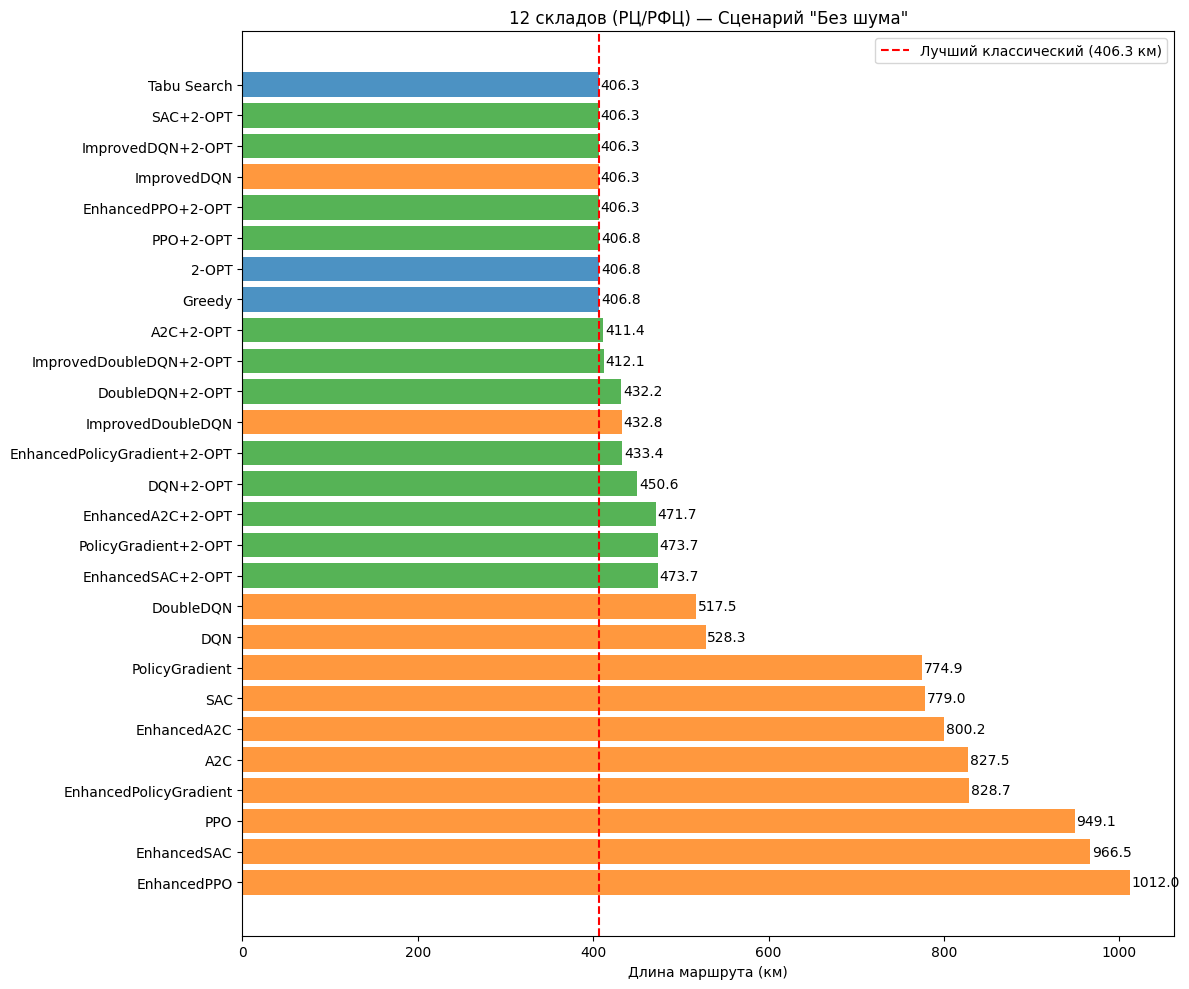

График сохранён: rl_results/rl_comparison_12.png

RL эксперименты для 29 складов
  Метрики загружены из models_rl_29_basic/PolicyGradient/PolicyGradient_metrics.json
  Загружен: PolicyGradient
  Метрики загружены из models_rl_29_basic/A2C/A2C_metrics.json
  Загружен: A2C
  Метрики загружены из models_rl_29_basic/PPO/PPO_metrics.json
  Загружен: PPO
  Метрики загружены из models_rl_29_basic/DQN/DQN_metrics.json
  Загружен: DQN
  Метрики загружены из models_rl_29_basic/DoubleDQN/DoubleDQN_metrics.json
  Загружен: DoubleDQN
  Метрики загружены из models_rl_29_basic/SAC/SAC_metrics.json
  Загружен: SAC
  Метрики загружены из models_rl_29_enhanced/EnhancedPolicyGradient/EnhancedPolicyGradient_metrics.json
  Загружен: EnhancedPolicyGradient
  Метрики загружены из models_rl_29_enhanced/EnhancedA2C/EnhancedA2C_metrics.json
  Загружен: EnhancedA2C
  Метрики загружены из models_rl_29_enhanced/EnhancedPPO/EnhancedPPO_metrics.json
  Загружен: EnhancedPPO
  Метрики загружены из models_rl_29_enhance

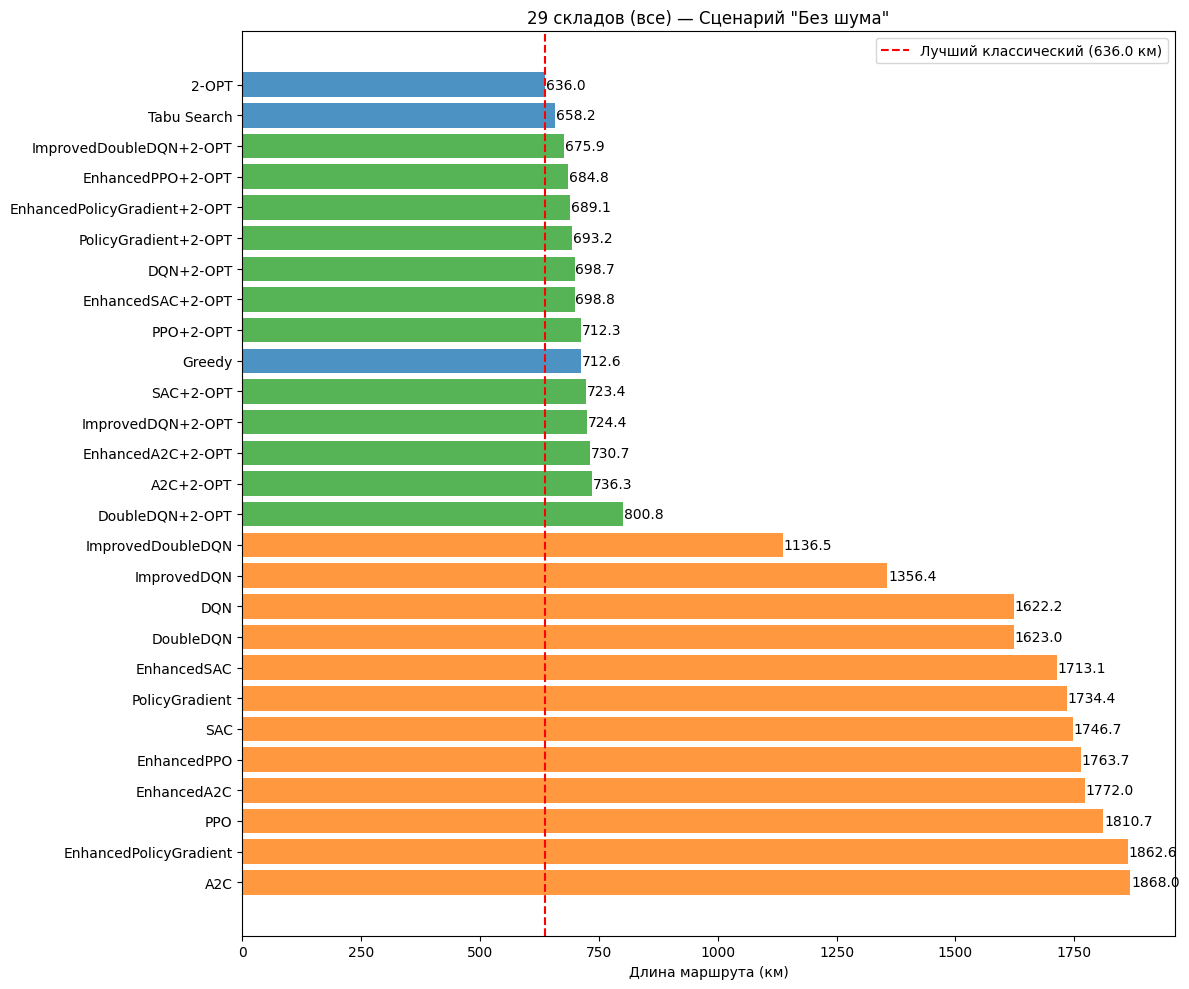

График сохранён: rl_results/rl_comparison_29.png
Папка rl_results заархивирована в rl_results.zip
Архив создан: rl_results.zip


In [ ]:
# 6. Точка входа
if __name__ == "__main__":
    df12, _ = run_rl_experiments(use_all=False)
    if df12 is not None:
        df12.to_csv(os.path.join(OUTPUT_DIR, "rl_results_12.csv"), index=False)
        plot_rl_comparison(df12, "12 складов (РЦ/РФЦ)", os.path.join(OUTPUT_DIR, "rl_comparison_12.png"))

    df29, _ = run_rl_experiments(use_all=True)
    if df29 is not None:
        df29.to_csv(os.path.join(OUTPUT_DIR, "rl_results_29.csv"), index=False)
        plot_rl_comparison(df29, "29 складов (все)", os.path.join(OUTPUT_DIR, "rl_comparison_29.png"))

    if df12 is not None and df29 is not None:
        combined = pd.concat([df12, df29], ignore_index=True)
        combined.to_csv(os.path.join(OUTPUT_DIR, "rl_results_all.csv"), index=False)

    if 'zip_folder' in globals():
        zip_folder(OUTPUT_DIR)
        print(f"Архив создан: {OUTPUT_DIR}.zip")